In [1]:
import numpy as np
## Import csv
X = np.loadtxt('time_series.csv', delimiter=',', skiprows=1, dtype=object)
## Remove first two columns
X = X[:, 2:]
## Convert to float
X = X.astype(np.float64)

In [2]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

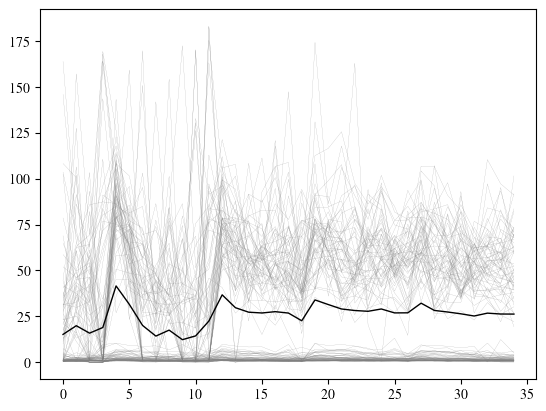

In [3]:
import matplotlib.pyplot as plt
plt.plot(X.T, markersize=2, linewidth=0.1, c='gray')
plt.plot(X.mean(axis=0), markersize=2, linewidth=1, c='black')
plt.show()

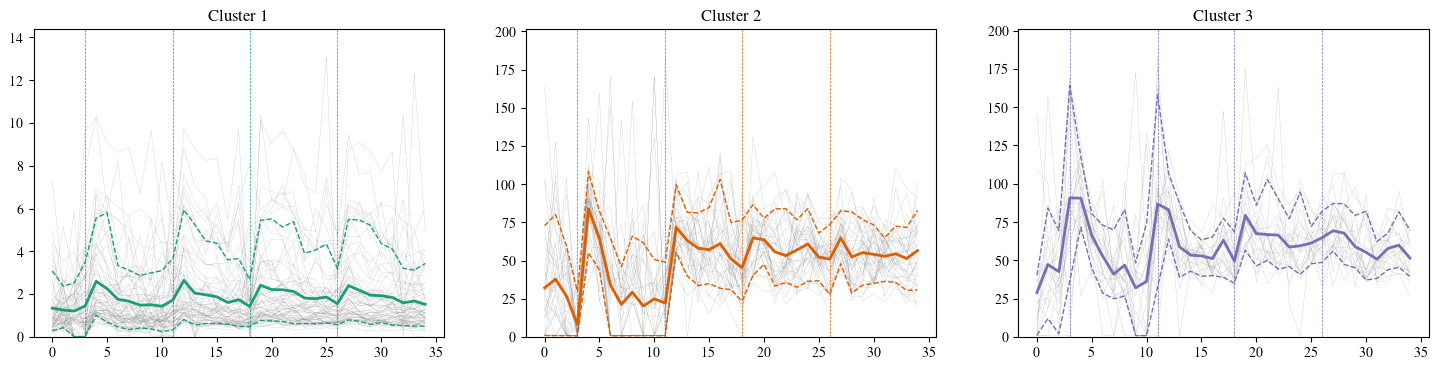

In [4]:
## K-means clustering on the time series data
from sklearn.cluster import KMeans
K = 3
jumps = np.array([ 3, 11, 18, 26])
kmeans = KMeans(n_clusters=K, random_state=0).fit(X)
## Colour palette
colors = plt.get_cmap('Dark2').colors
## Plot the clusters in three separate plots
fig, ax = plt.subplots(1, K, figsize=(6 * K, 4))
for k in range(K):
    Xl = X[kmeans.labels_ == k]
    Xlm = Xl.mean(axis=0)
    ax[k].plot(Xl.T, markersize=2, linewidth=0.1, c='gray')
    ## Percentile lines
    percentXl = np.percentile(Xl, [10, 90], axis=0)
    ## Plot the percentiles
    ax[k].plot(percentXl[0], markersize=2, linewidth=1, color=colors[k], linestyle='--')
    ax[k].plot(percentXl[1], markersize=2, linewidth=1, color=colors[k], linestyle='--')
    for jump in jumps:
        ax[k].axvline(x=jump, color=colors[k], linestyle='--', linewidth=0.5)
    ax[k].plot(Xlm, markersize=2, linewidth=2, color=colors[k])
    ax[k].set_title('Cluster ' + str(k+1))
    ax[k].set_ylim(0, np.max(Xl)+ np.max(Xl) / 10)
plt.savefig('time_series_clusters.pdf', bbox_inches='tight')
plt.show()


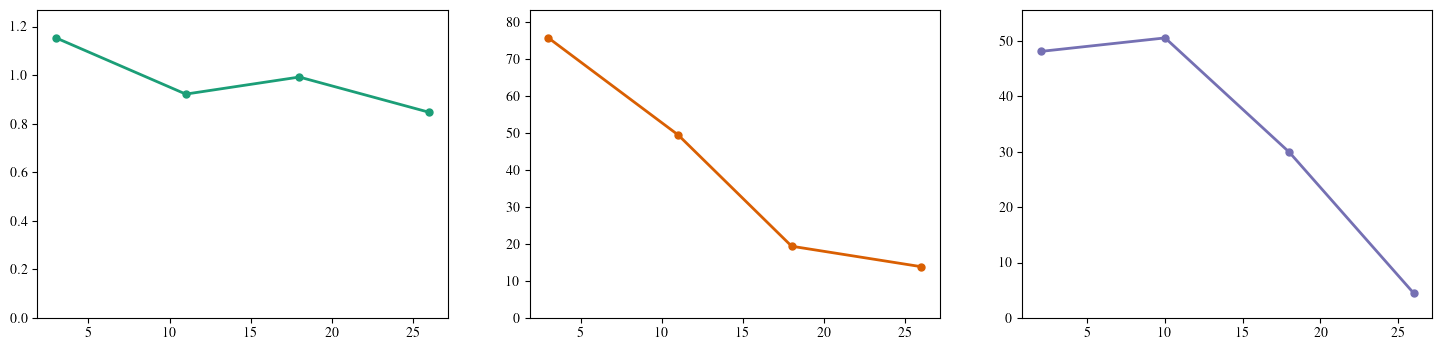

In [5]:
from sklearn.linear_model import LinearRegression
## Plot the clusters in three separate plots
fig, ax = plt.subplots(1, K, figsize=(6 * K, 4))
for k in range(K):
    if k == 2:
        jumpss = np.copy(jumps)
        jumpss[:2] = jumps[:2] - 1  # Adjust for zero-based indexing
    Xlm = X[kmeans.labels_ == k].mean(axis=0)
    v = np.diff(Xlm)[jumps if k != 2 else jumpss]
    ax[k].plot(jumps if k != 2 else jumpss, v, markersize=5, linewidth=2, color=colors[k], marker='o')
    ax[k].set_ylim(0, np.max(v) + np.max(v) / 10)
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## Baseline
lambda0 = 0.1
## Parameters for the hierarchical Hawkes process
alpha = np.append([0], np.diff(X[kmeans.labels_ == 0].mean(axis=0))[jumps])
beta = np.array([0.0, 1.0, 0.5, 0.25, 0.1]) / 10
## Grid
time_grid = np.linspace(0, 35, 1000)
indices = np.searchsorted(jumps, time_grid)
ints = lambda0 + np.maximum(0, alpha[indices] - beta[indices] * (time_grid - np.array(jumps)[indices-1]))


In [7]:
import numpy as np
import matplotlib.pyplot as plt
## Jumps 
jumps = np.array([ 3, 11, 18, 26]) + 1
## Baseline
lambda0 = 1.3
## Parameters for the hierarchical Hawkes process
alpha = np.append([0], np.diff(X[kmeans.labels_ == 0].mean(axis=0))[jumps-1])
alpha[1] = 1.35
alpha[2] = 1.15
beta = np.array([0.0, 0.35, 0.275, 0.215, 0.2]) 
## Grid
time_grid = np.linspace(0, 35, 1000)
indices = np.searchsorted(jumps, time_grid)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    ## ints += np.maximum(0, alpha[j+1] - beta[j+1] * (time_grid - jump - 1)) * np.heaviside(time_grid - jump - 1, 0)
    ints += alpha[j+1] * np.exp(- beta[j+1] * (time_grid - jump)) * np.heaviside(time_grid - jump, 0)

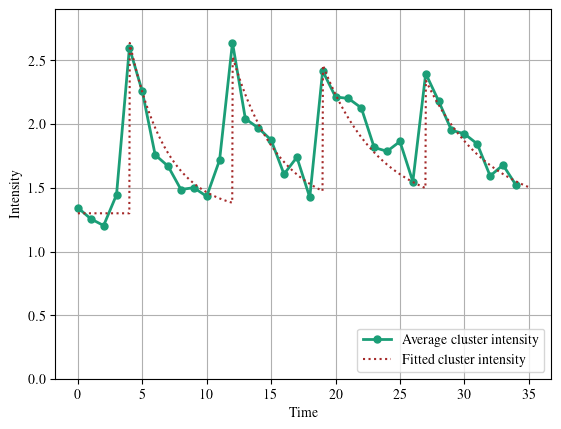

In [8]:
plt.plot(X[kmeans.labels_ == 0].mean(axis=0), color=colors[0], linewidth=2, marker='o', markersize=5, label='Average cluster intensity')
plt.plot(time_grid,ints, color='brown', linewidth=1.5, ls='dotted', label='Fitted cluster intensity')
plt.ylim(0, np.max(ints) + np.max(ints) / 10)
plt.xlabel('Time')
plt.ylabel('Intensity')
## Legend in bottom right
plt.legend(loc='lower right')
plt.grid()
plt.savefig('hierarchical_hawkes_intensity_0.pdf', bbox_inches='tight')
plt.show()

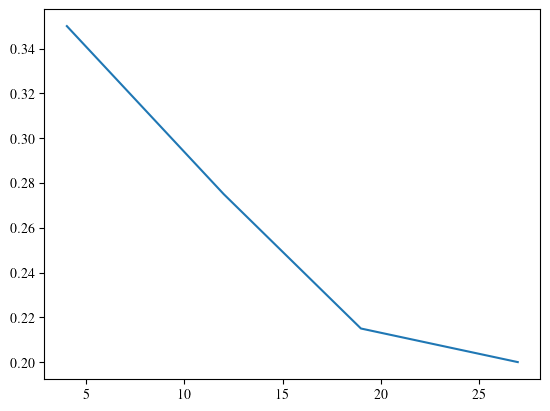

In [9]:
plt.plot(jumps, beta[1:])

In [10]:
## Baseline
lambda0 = 1.3
## Parameters for the hierarchical Hawkes process
alpha = np.append([0], np.diff(X[kmeans.labels_ == 0].mean(axis=0))[jumps])
alpha[1] = 1.35
alpha[2] = 1.15
beta = np.array([0.0, 0.35, 0.25, 0.2, 0.2]) 
## Grid
time_grid = np.linspace(0, 35, 1000)
indices = np.searchsorted(jumps, time_grid)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    ## ints += np.maximum(0, alpha[j+1] - beta[j+1] * (time_grid - jump - 1)) * np.heaviside(time_grid - jump - 1, 0)
    ints += alpha[j+1] * np.exp(- beta[j+1] * (time_grid - jump - 1)) * np.heaviside(time_grid - jump - 1, 0)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def inhibitory_hawkes_intensity(times, shocks, alpha0, beta, theta):
    times = np.array(times)
    shocks = np.array(shocks)
    intensity = np.full_like(times, fill_value=alpha0, dtype=np.float64)
    for shock in shocks:
        affected = (times > shock)
        intensity[affected] -= beta * np.exp(-theta * (times[affected] - shock))
    # Ensure intensity does not drop below zero
    intensity = np.maximum(intensity, 0)
    return intensity


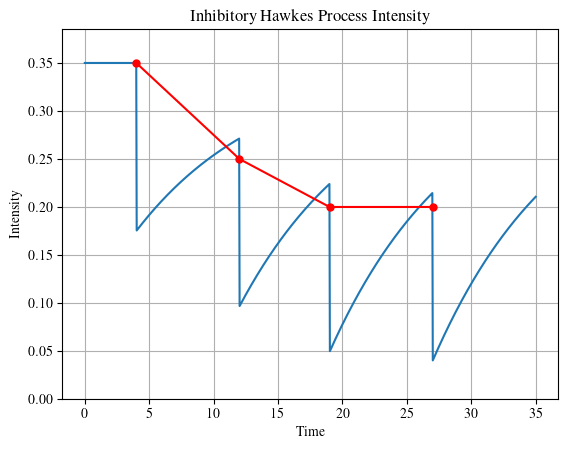

In [12]:
times = np.linspace(0, 35, 1000)
alpha0 = 0.35
gamma_alpha = 0.175
theta_alpha = 0.1

intensity = inhibitory_hawkes_intensity(times, jumps, alpha0, gamma_alpha, theta_alpha)

plt.plot(times, intensity)
plt.plot(jumps, beta[1:], marker='o', markersize=5, color='red')
plt.ylim(0, np.max(intensity) + np.max(intensity) / 10)
plt.title("Inhibitory Hawkes Process Intensity")
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.grid(True)
plt.show()


In [13]:
inhibitory_hawkes_intensity(jumps, jumps, alpha0, gamma_alpha, theta_alpha)

array([0.35      , 0.27136743, 0.22404979, 0.21477436])

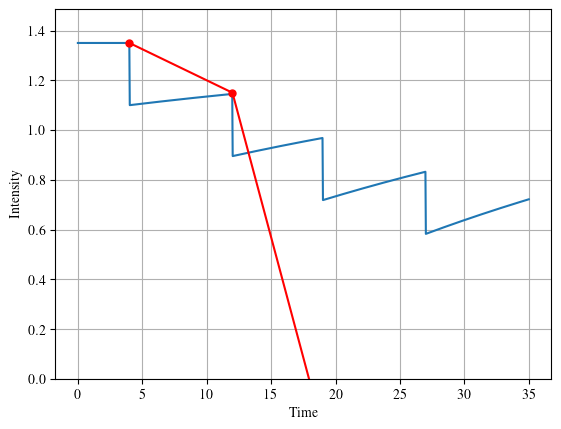

In [14]:
times = np.linspace(0, 35, 1000)
alpha0 = alpha[1]
gamma_alpha = 0.25
theta_alpha = 0.025

intensity = inhibitory_hawkes_intensity(times, jumps, alpha0, gamma_alpha, theta_alpha)

plt.plot(times, intensity)
plt.plot(jumps, alpha[1:], marker='o', markersize=5, color='red')
plt.ylim(0, np.max(intensity) + np.max(intensity) / 10)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.grid(True)
plt.show()

In [15]:
## Maximum likelihood estimation of the parameters
def negative_log_likelihood(params, time_series, jumps):
    lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta = np.exp(params)
    alphas = inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
    betas = inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
    ## Grid
    time_grid = np.arange(len(time_series))
    ints = np.ones_like(time_grid) * lambda0
    # Calculate the intensity function
    for j, jump in enumerate(jumps):
        ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1)
    ## Loss function
    loss = np.sum((ints - time_series) ** 2)
    return loss


In [16]:
from scipy.optimize import minimize
jumps = np.array([3, 11, 18, 26]) + 1  # Adjust for zero-based indexing
# Initial parameter guess
params = np.log([1.3, 0.35, 0.25, 0.025, 0.35, 0.2, 0.1])
# Minimize the negative log-likelihood
result = minimize(negative_log_likelihood, params, args=(X[kmeans.labels_ == 0].mean(axis=0), jumps), method='L-BFGS-B')
# Extract the optimized parameters
optimized_params = np.exp(result.x)


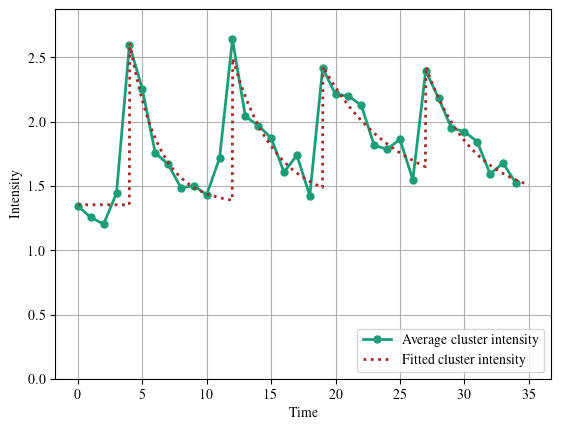

In [17]:
## Plot the optimized intensity function
lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta = optimized_params
alphas = inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas = inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
## Grid
time_grid = np.linspace(0, 35, 1000)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1)
plt.plot(X[kmeans.labels_ == 0].mean(axis=0), color=colors[0], linewidth=2, marker='o', markersize=5, label='Average cluster intensity')
plt.plot(time_grid, ints, color='brown', linewidth=2, ls='dotted', label='Fitted cluster intensity')
plt.ylim(0, np.max(ints) + np.max(ints) / 10)
plt.xlabel('Time')
plt.ylabel('Intensity')
## Legend in bottom right
plt.legend(loc='lower right')
plt.grid()
## plt.savefig('hierarchical_hawkes_intensity_optimized.pdf', bbox_inches='tight')
plt.show()

In [ ]:
## Minimize the least squares loss function around each inhibitory intensity
def inhibitory_loss(params, obs, jumps):
    theta0, eta, csi = np.exp(params)
    preds = inhibitory_hawkes_intensity(jumps, jumps, theta0, eta, csi)
    ## Loss function
    loss = np.sum((obs - preds) ** 2)
    return loss

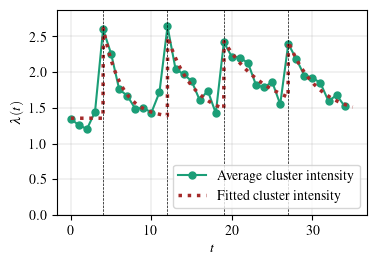

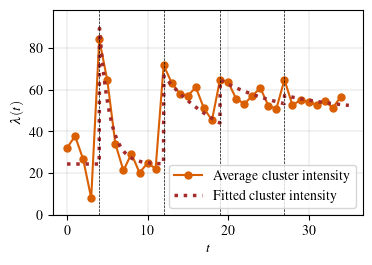

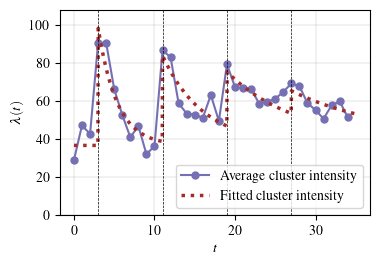

In [64]:
## Repeat for all clusters
optimized_params_full = {}
for k in range(K):
    jumps = np.array([3, 11, 18, 26]) + 1  # Adjust for zero-based indexing
    if k == 2:
        jumps = np.copy(jumps)
        jumps[:2] = jumps[:2] - 1
    # Initial parameter guess
    Xlm = X[kmeans.labels_ == k].mean(axis=0)
    lambda0 = np.mean(Xlm[:jumps[0]])
    alphas0 = np.diff(Xlm)[jumps - 1]
    theta0_alpha0 = alphas0[0]
    eta_alpha0 = np.abs(alphas0[1] - alphas0[0])
    csi_alpha0 = 0.1  # Initial guess for csi
    params = np.log([theta0_alpha0, eta_alpha0, csi_alpha0])
    res_alpha = minimize(inhibitory_loss, params, args=(alphas0, jumps), method='L-BFGS-B')
    params = np.log([lambda0] + list(np.exp(res_alpha.x)) + [0.35, 0.2, 0.1])
    # Minimize the negative log-likelihood
    result = minimize(negative_log_likelihood, params, args=(X[kmeans.labels_ == k].mean(axis=0), jumps), method='L-BFGS-B')
    # Extract the optimized parameters
    optimized_params = np.exp(result.x)
    optimized_params_full[k] = optimized_params
    ## Plot the optimized intensity function
    lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta = optimized_params
    alphas = inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
    betas = inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
    ## Grid
    time_grid = np.linspace(0, X.shape[1], 1000)
    ints = np.ones_like(time_grid) * lambda0
    # Calculate the intensity function
    for j, jump in enumerate(jumps):
        ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1)
    plt.figure(figsize=(4, 4 * 2/3))
    plt.plot(Xlm, color=colors[k], linewidth=1.5, marker='o', markersize=5,
             label='Average cluster intensity')
    plt.plot(time_grid, ints, color='brown', linewidth=2.5, ls='dotted', label='Fitted cluster intensity')
    plt.ylim(0, np.max(ints) + np.max(ints) / 10)
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\lambda(t)$')
    for jump in jumps:
        plt.axvline(x=jump, color='black', linestyle='--', linewidth=0.5)
    ## Legend in bottom right
    plt.legend(loc='lower right')
    plt.grid(linewidth=0.25)
    ## plt.title(f'Cluster {k+1}')
    plt.savefig(f'hierarchical_hawkes_intensity_optimized_{k}.pdf', bbox_inches='tight')
    plt.show()

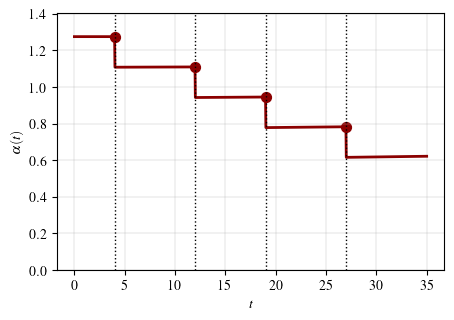

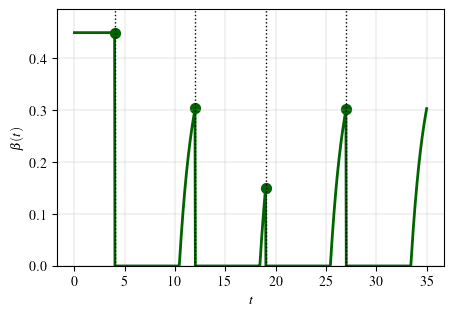

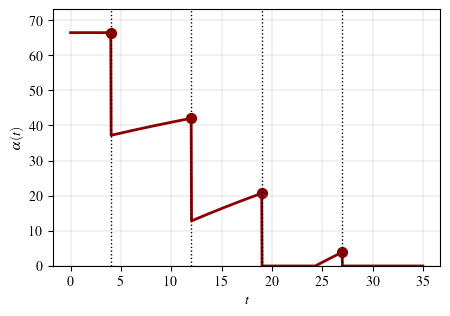

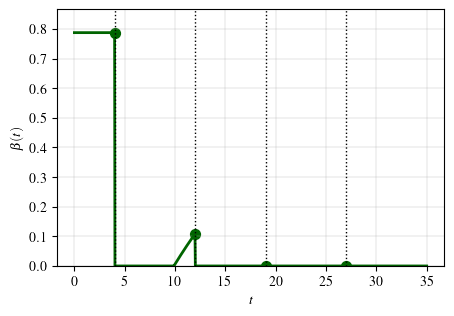

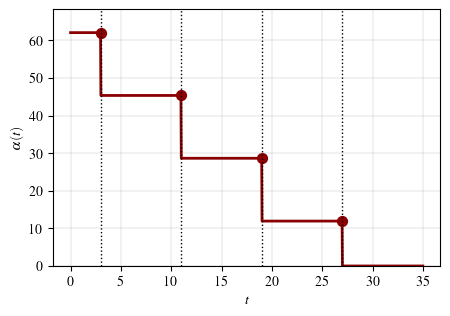

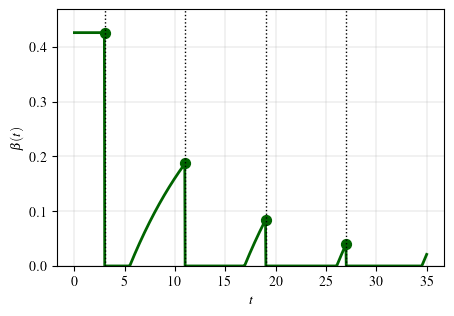

In [63]:
## Plot intensities of alpha and beta for all clusters
time_grid = np.linspace(0, X.shape[1], 1000)
for k in range(K):
    jumps = np.array([3, 11, 18, 26]) + 1  # Adjust for zero-based indexing
    if k == 2:
        jumps = np.copy(jumps)
        jumps[:2] = jumps[:2] - 1
    # ## Intensities for alpha and beta
    lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta = optimized_params_full[k]
    ints_alpha = inhibitory_hawkes_intensity(time_grid, jumps, theta0_alpha, eta_alpha, csi_alpha)
    ints_beta = inhibitory_hawkes_intensity(time_grid, jumps, theta0_beta, eta_beta, csi_beta)
    alphas = inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
    betas = inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
    ## Plot the intensity function for alpha
    plt.figure(figsize=(5, 4 * 5/6))
    plt.plot(time_grid, ints_alpha, color='darkred', linewidth=2, label='Fitted alpha intensity')
    plt.scatter(jumps, alphas, color='darkred', s=50, label='Intensity at jumps')
    plt.ylim(0, np.max(ints_alpha) + np.max(ints_alpha) / 10)
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\alpha(t)$')
    for jump in jumps:
        plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
    plt.grid(linewidth=0.25)
    plt.savefig(f'intensity_alpha_{k}.pdf', bbox_inches='tight')
    plt.show()
    ## Repeat for beta
    plt.figure(figsize=(5, 4 * 5/6))
    plt.plot(time_grid, ints_beta, color='darkgreen', linewidth=2, label='Fitted beta intensity')
    plt.scatter(jumps, betas, color='darkgreen', s=50, label='Intensity at jumps')
    plt.ylim(0, np.max(ints_beta) + np.max(ints_beta) / 10)
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\beta(t)$')
    for jump in jumps:
        plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
    plt.grid(linewidth=0.25)
    plt.savefig(f'intensity_beta_{k}.pdf', bbox_inches='tight')
    plt.show()
    

In [65]:
optimized_params_full

{0: array([1.35431035e+00, 1.27530955e+00, 1.67105442e-01, 1.13690870e-03,
        4.49239625e-01, 4.35551695e+01, 7.12481062e-01]),
 1: array([2.43777563e+01, 6.64356971e+01, 2.92464789e+01, 2.27570048e-02,
        7.87578862e-01, 1.19329508e+00, 7.05902822e-02]),
 2: array([3.66534369e+01, 6.20432790e+01, 1.67029586e+01, 1.51944782e-10,
        4.25766177e-01, 5.53687221e-01, 1.05258694e-01])}

In [22]:
## Repeat for other clusters
for k in range(1, 1):
    jumps = np.array([3, 11, 18, 26]) + 1  # Adjust for zero-based indexing
    if k == 2:
        jumps = np.copy(jumps)
        jumps[:2] = jumps[:2] - 1
    # Initial parameter guess
    Xlm = X[kmeans.labels_ == k].mean(axis=0)
    lambda0 = np.mean(Xlm[:jumps[0]])
    alphas0 = np.diff(Xlm)[jumps - 1]
    theta0_alpha0 = alphas0[0]
    eta_alpha0 = np.abs(alphas0[1] - alphas0[0])
    csi_alpha0 = 0.1  # Initial guess for csi
    params = np.log([theta0_alpha0, eta_alpha0, csi_alpha0])
    res_alpha = minimize(inhibitory_loss, params, args=(alphas0, jumps), method='L-BFGS-B')

In [23]:
res_alpha.x

array([  4.02546369,   2.71902536, -22.60750394])

In [45]:
import numpy as np
### For jumps at 5, 15, 20, 40, simulate a hierarchical Hawkes function with inhibitory effects and some decent parameters.
jumps = np.array([5, 15, 20, 40])
lambda0 = 0.1
theta0_alpha = 0.25
theta0_beta = 0.5
eta_alpha = 0.2
eta_beta = 0.3
csi_alpha = 0.1
csi_beta = 0.05
## Calculate the values of alpha and beta at the jumps
alphas = inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas = inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
## Generate the time grid
time_grid = np.linspace(0, 50, 1000)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1)
## Intensities for alpha and beta
ints_alpha = inhibitory_hawkes_intensity(time_grid, jumps, theta0_alpha, eta_alpha, csi_alpha)
ints_beta = inhibitory_hawkes_intensity(time_grid, jumps, theta0_beta, eta_beta, csi_beta)



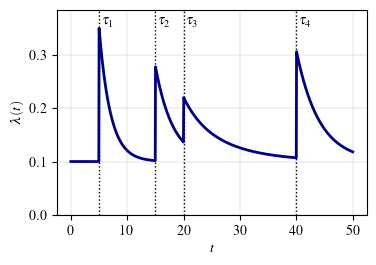

In [50]:
## Plot the intensity function
plt.figure(figsize=(4, 4 * 2/3))
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints, color='darkblue', linewidth=2, label='Fitted cluster intensity')
plt.ylim(0, np.max(ints) + np.max(ints) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\lambda(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump + 1.5, np.max(ints) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
plt.savefig('example1_lambda.pdf', bbox_inches='tight')
plt.show()


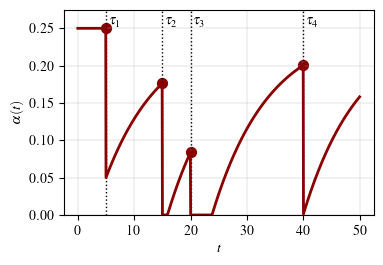

In [51]:
## Plot the intensity function
plt.figure(figsize=(4, 4 * 2/3))
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints_alpha, color='darkred', linewidth=2, label='Fitted cluster intensity')
plt.scatter(jumps, alphas, color='darkred', s=50, label='Intensity at jumps')
plt.ylim(0, np.max(ints_alpha) + np.max(ints_alpha) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump + 1.5, np.max(ints_alpha) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
plt.savefig('example1_alpha.pdf', bbox_inches='tight')
plt.show()

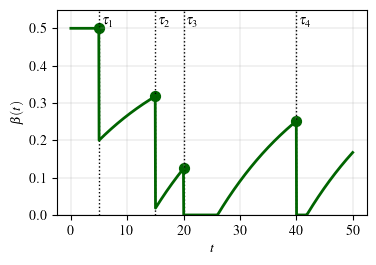

In [52]:
plt.figure(figsize=(4, 4 * 2/3))
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints_beta, color='darkgreen', linewidth=2, label='Fitted cluster intensity')
plt.scatter(jumps, betas, color='darkgreen', s=50, label='Intensity at jumps')
plt.ylim(0, np.max(ints_beta) + np.max(ints_beta) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\beta(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump + 1.5, np.max(ints_beta) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
plt.savefig('example1_beta.pdf', bbox_inches='tight')
plt.show()

In [28]:
import numpy as np
### For jumps at 5, 15, 20, 40, simulate a hierarchical Hawkes function with inhibitory effects and some decent parameters.
jumps = np.array([5, 15, 20, 40])
lambda0 = 0.1
theta0_alpha = 0.25
theta0_beta = 0.5
eta_alpha = 0.2
eta_beta = 0.3
csi_alpha = 0.1
csi_beta = 0.05
## Calculate the values of alpha and beta at the jumps
alphas = inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas = inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
## Generate the time grid
time_grid = np.linspace(0, 50, 1000)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    ints += alphas[j] * np.exp(-betas[j] * (time_grid - jump)) * np.heaviside(time_grid - jump, 1)
## Intensities for alpha and beta
ints_alpha = inhibitory_hawkes_intensity(time_grid, jumps, theta0_alpha, eta_alpha, csi_alpha)
ints_beta = inhibitory_hawkes_intensity(time_grid, jumps, theta0_beta, eta_beta, csi_beta)

